  0%|          | 0/55 [00:00<?, ?it/s]

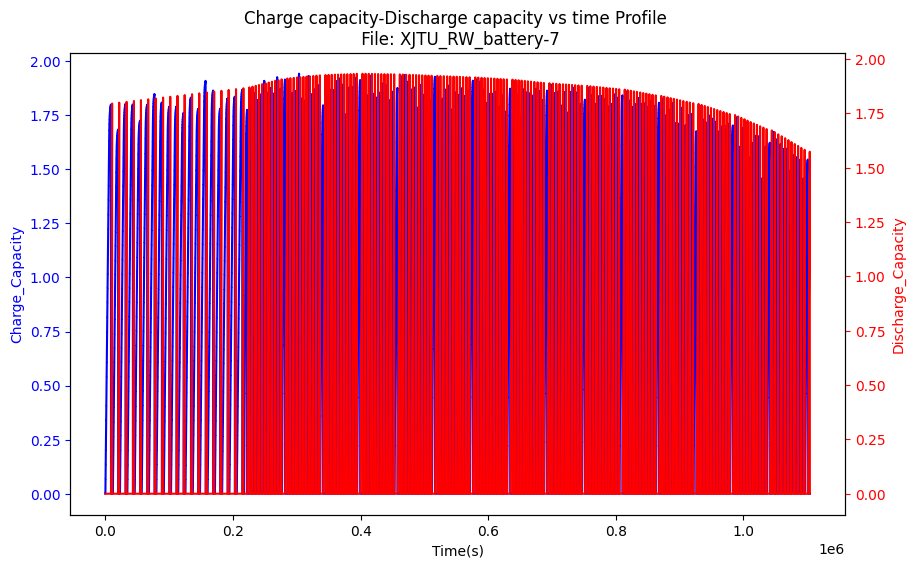

  2%|▏         | 1/55 [00:01<01:20,  1.48s/it]

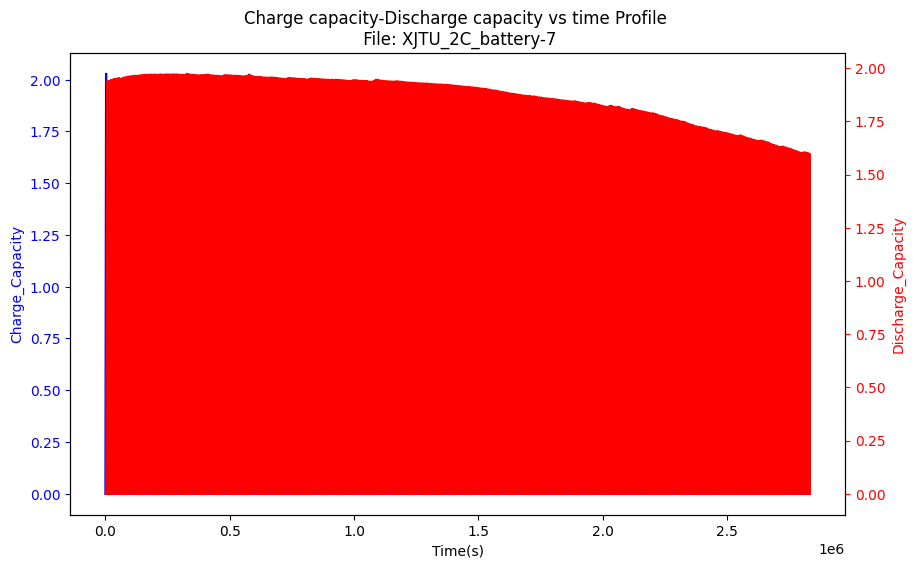

  4%|▎         | 2/55 [00:05<02:33,  2.89s/it]

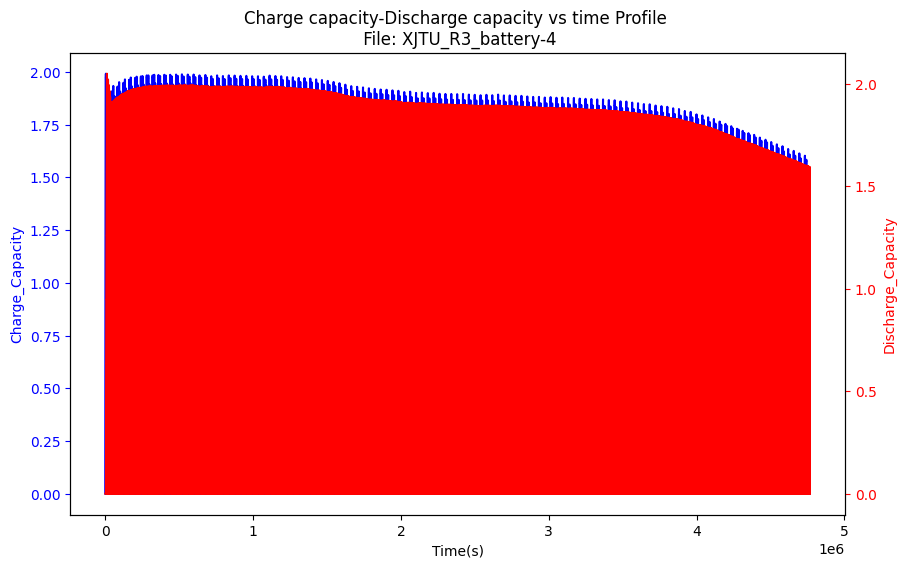

  5%|▌         | 3/55 [00:11<03:59,  4.60s/it]

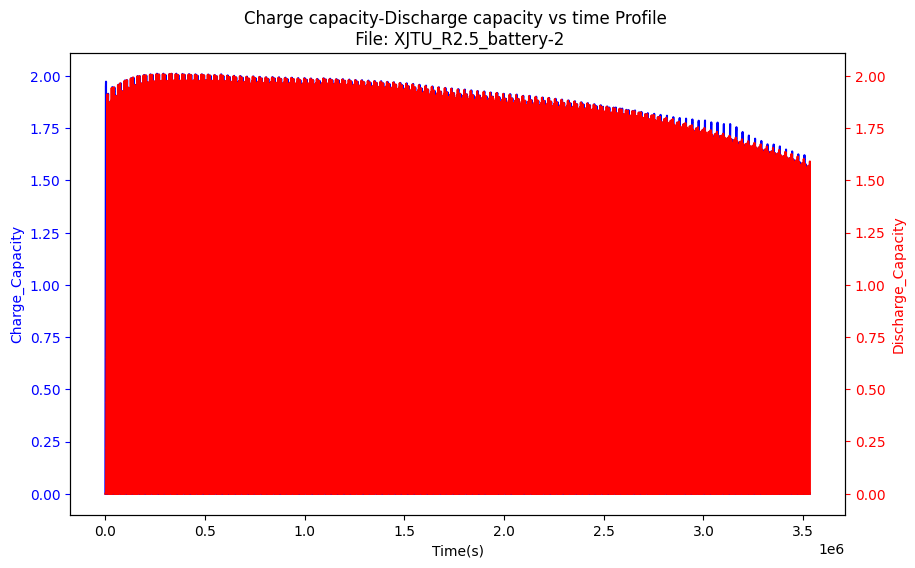

  7%|▋         | 4/55 [00:17<04:04,  4.79s/it]

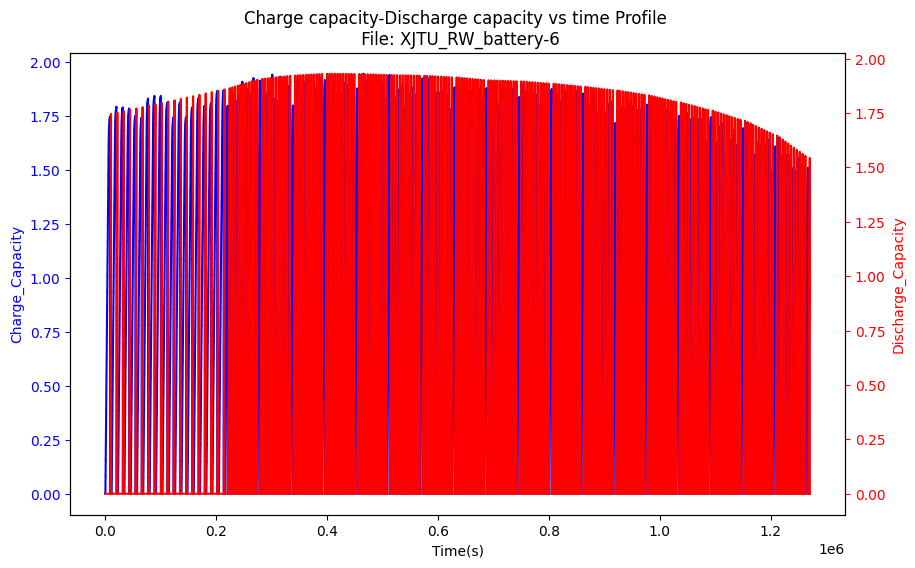

  9%|▉         | 5/55 [00:18<03:05,  3.71s/it]

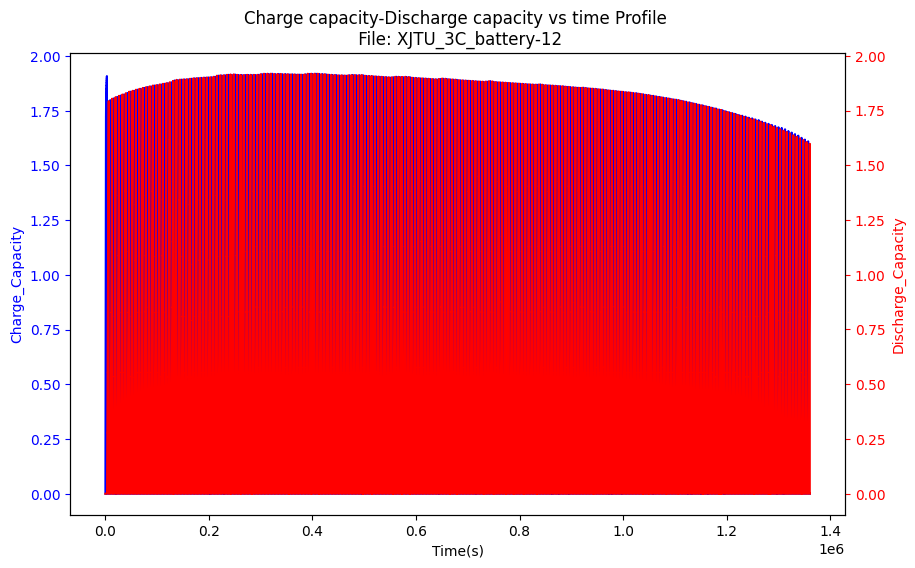

 11%|█         | 6/55 [00:20<02:32,  3.12s/it]

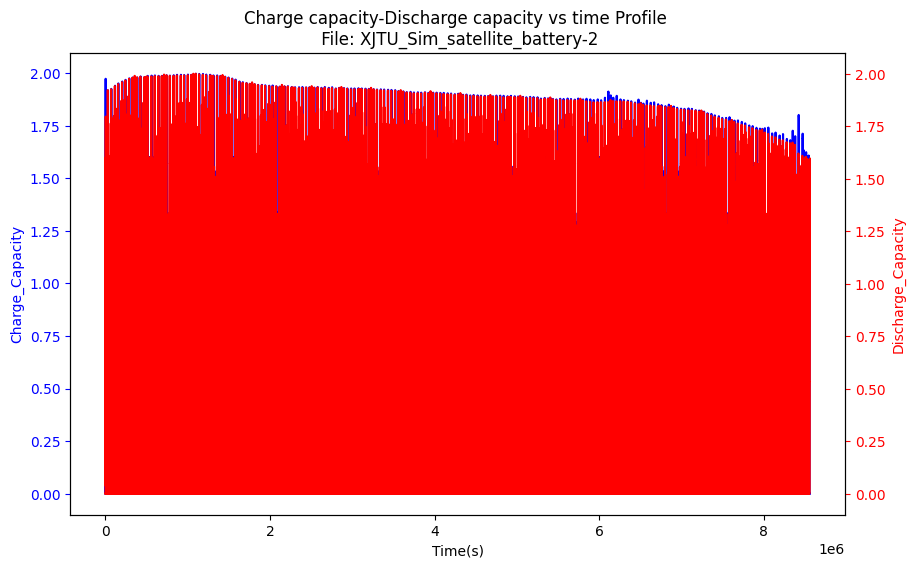

 13%|█▎        | 7/55 [00:30<04:18,  5.39s/it]

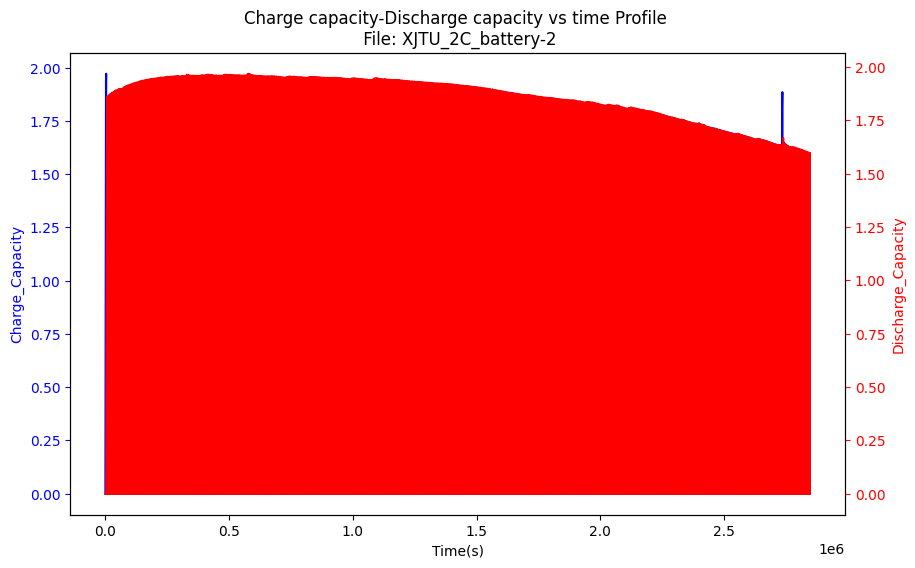

 15%|█▍        | 8/55 [00:35<03:57,  5.05s/it]

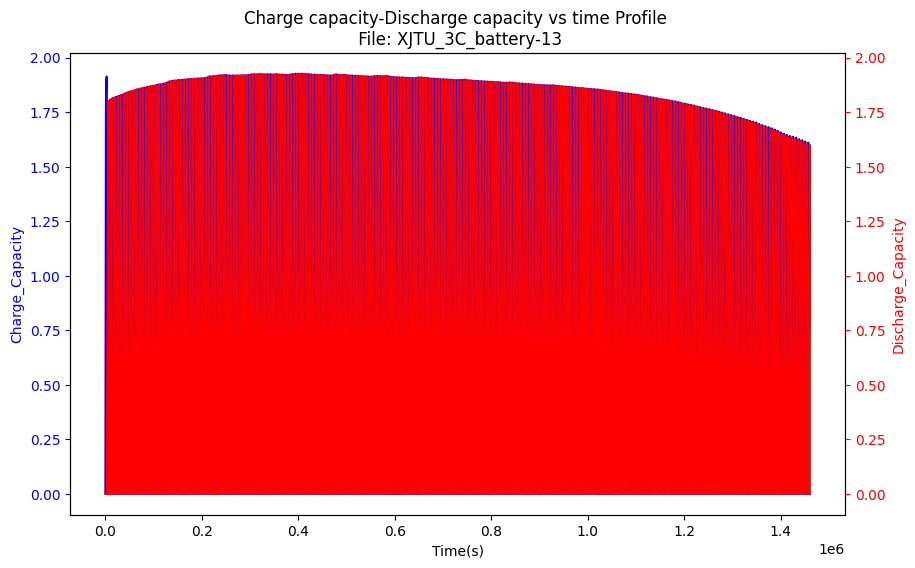

 16%|█▋        | 9/55 [00:37<03:10,  4.15s/it]

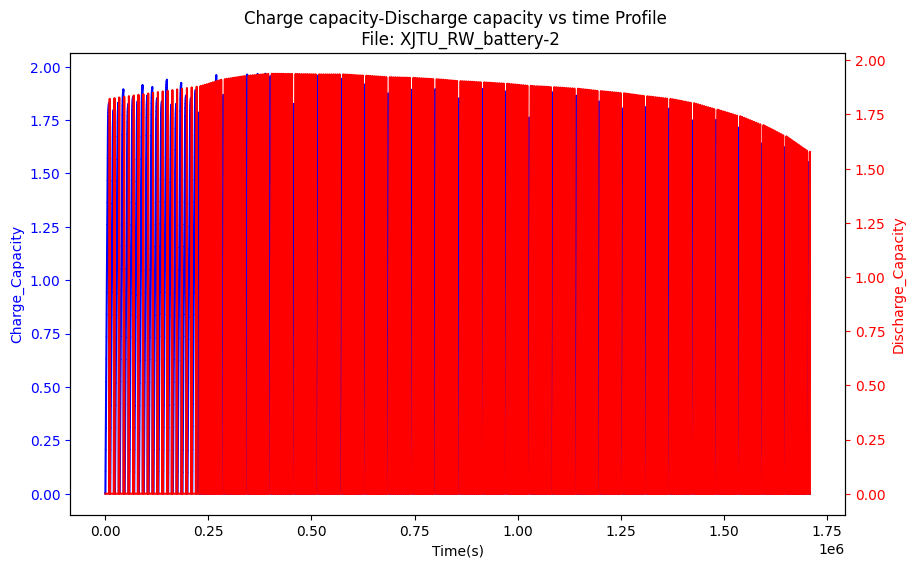

 18%|█▊        | 10/55 [00:39<02:39,  3.54s/it]

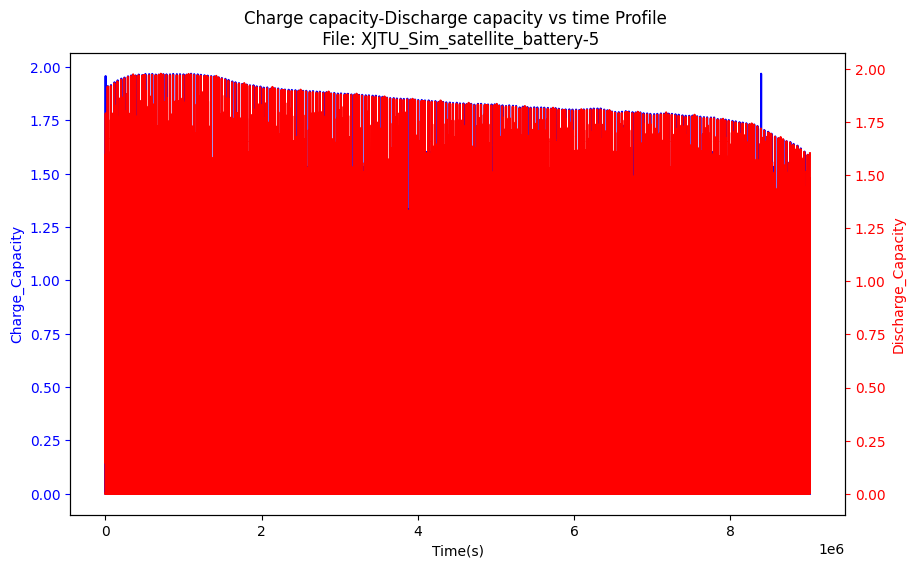

 20%|██        | 11/55 [00:49<04:08,  5.64s/it]

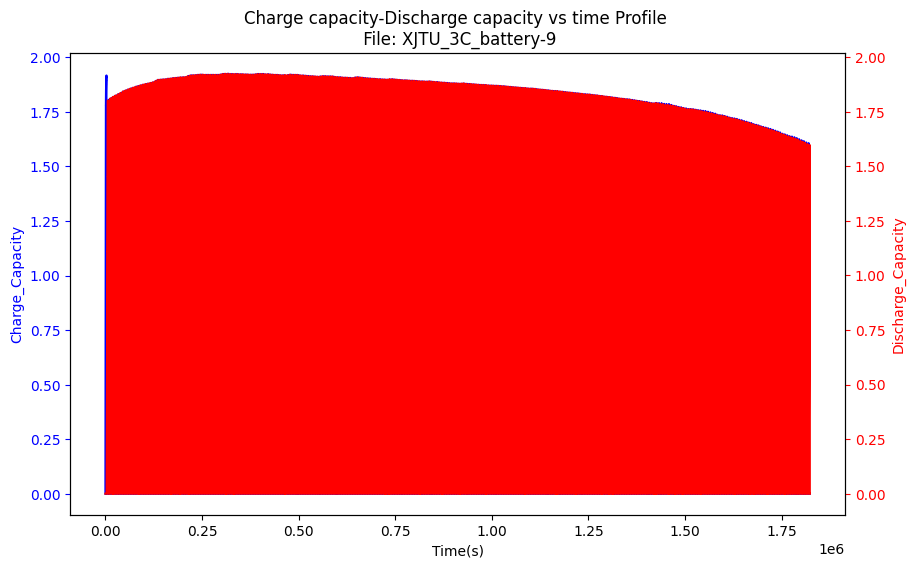

 22%|██▏       | 12/55 [00:53<03:30,  4.90s/it]

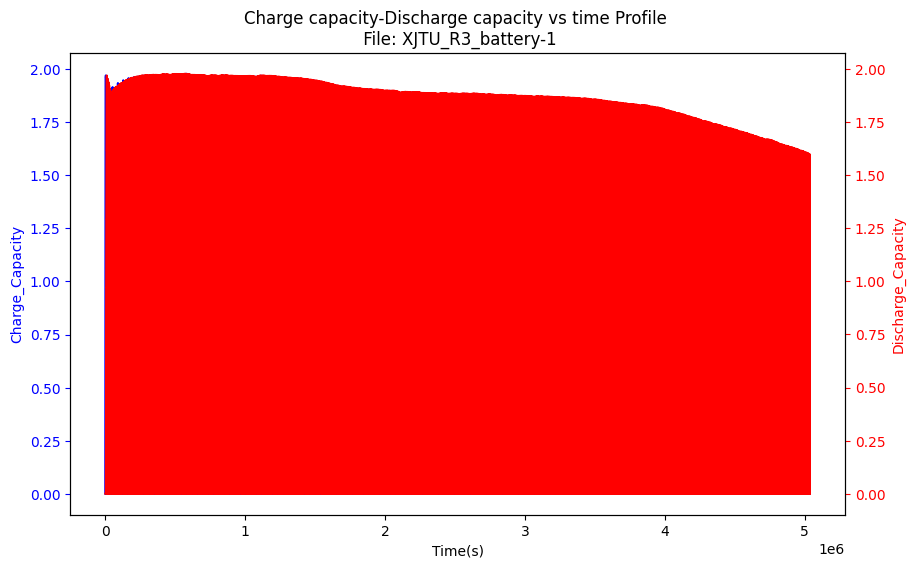

 24%|██▎       | 13/55 [00:59<03:40,  5.25s/it]

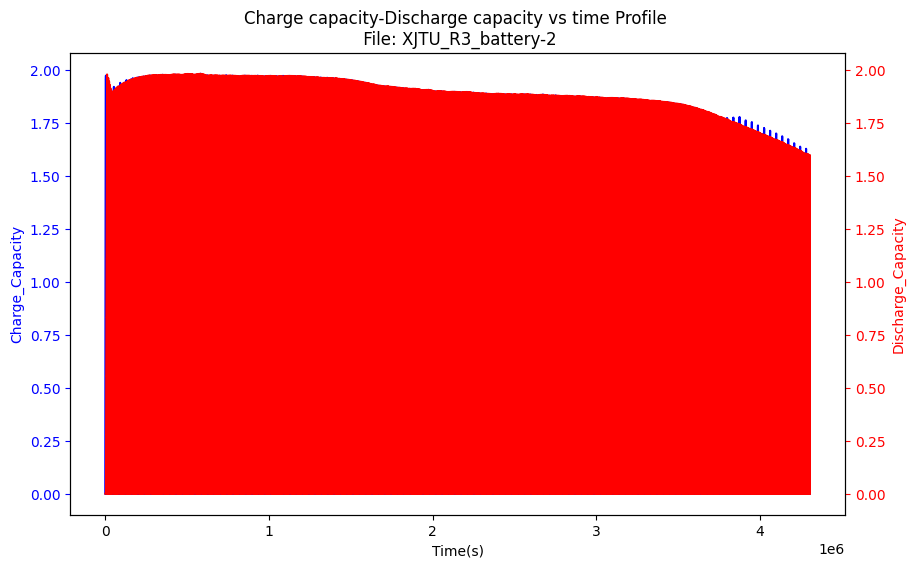

 25%|██▌       | 14/55 [01:05<03:49,  5.61s/it]

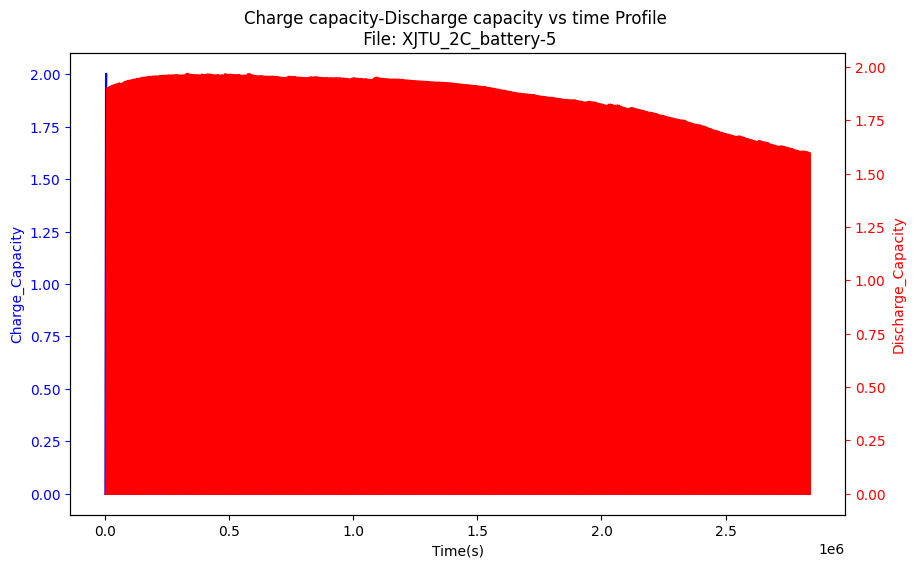

 27%|██▋       | 15/55 [01:09<03:25,  5.14s/it]

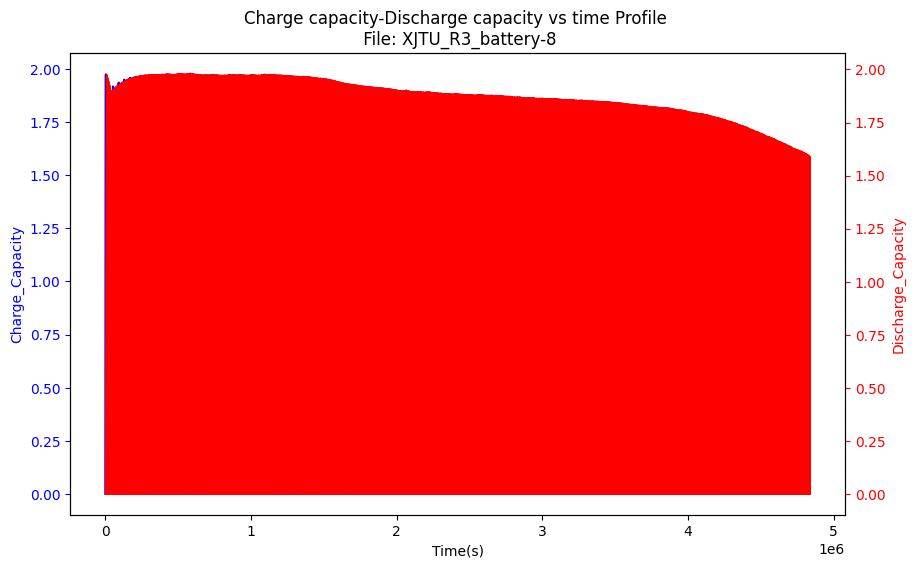

 29%|██▉       | 16/55 [01:15<03:31,  5.43s/it]

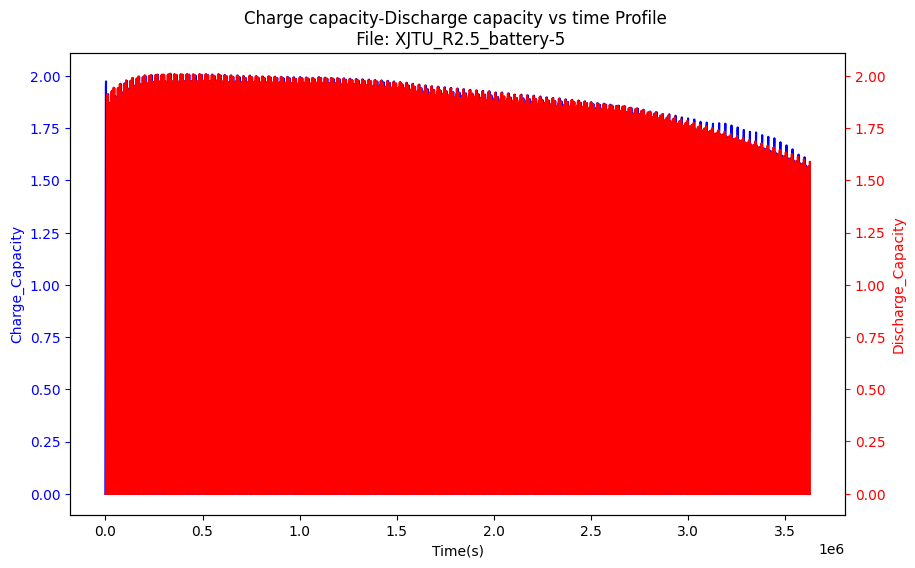

 31%|███       | 17/55 [01:21<03:25,  5.41s/it]

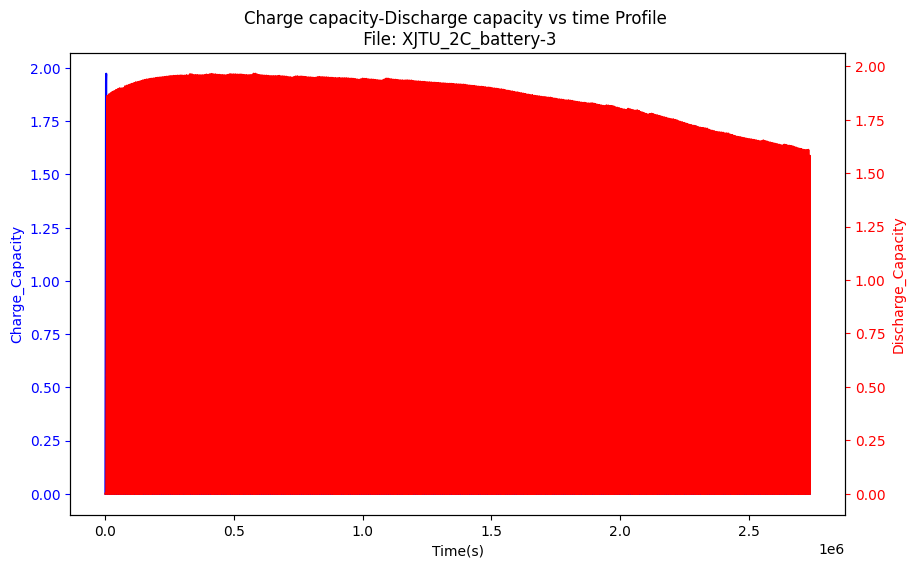

 33%|███▎      | 18/55 [01:25<03:03,  4.96s/it]

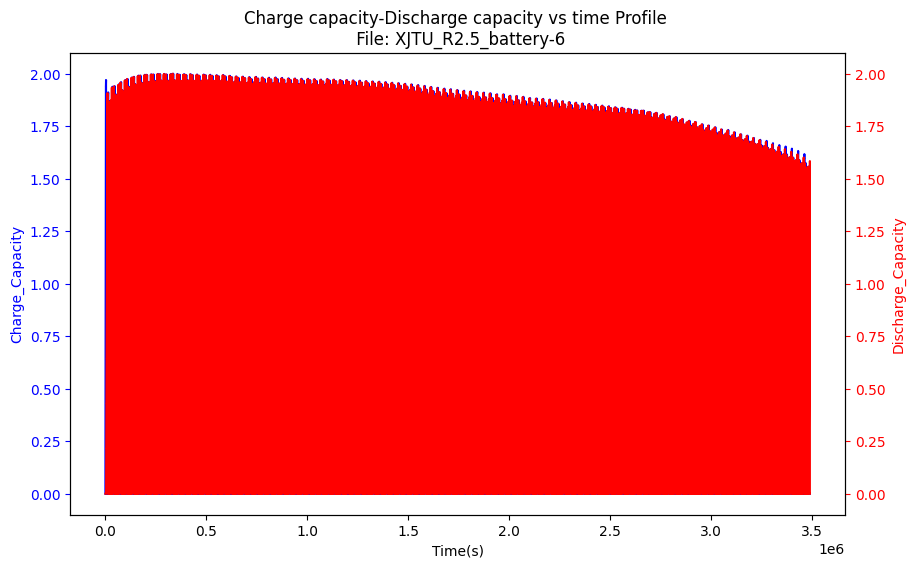

 35%|███▍      | 19/55 [01:30<02:58,  4.96s/it]

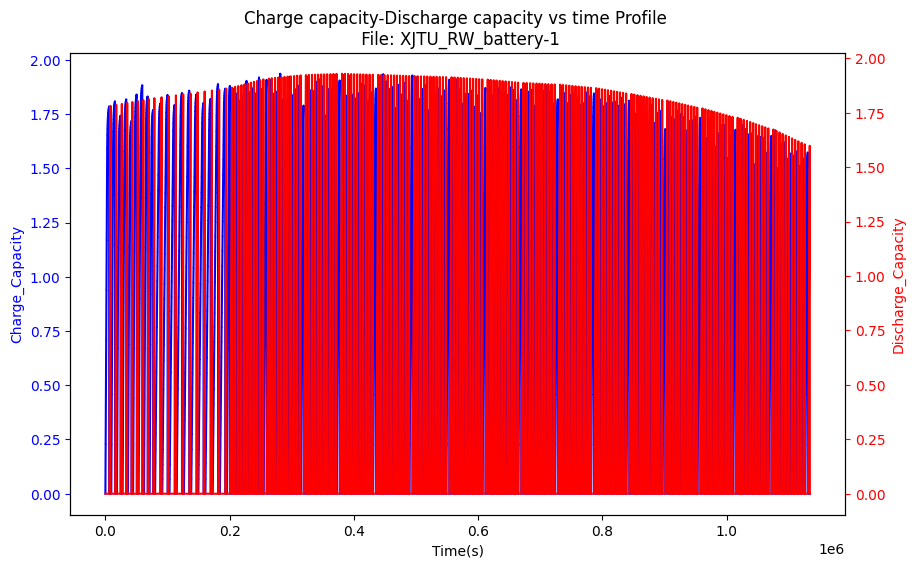

 36%|███▋      | 20/55 [01:31<02:19,  3.97s/it]

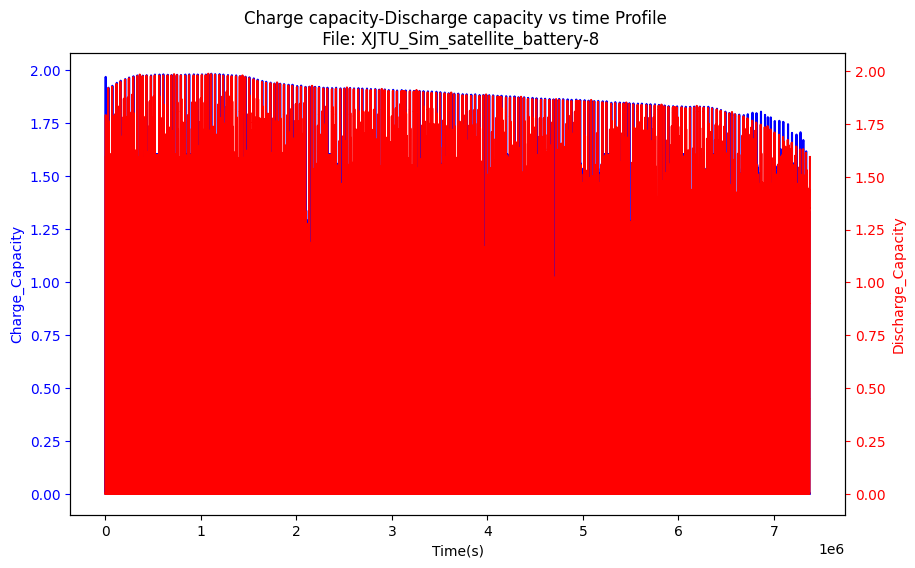

 38%|███▊      | 21/55 [01:40<02:59,  5.29s/it]

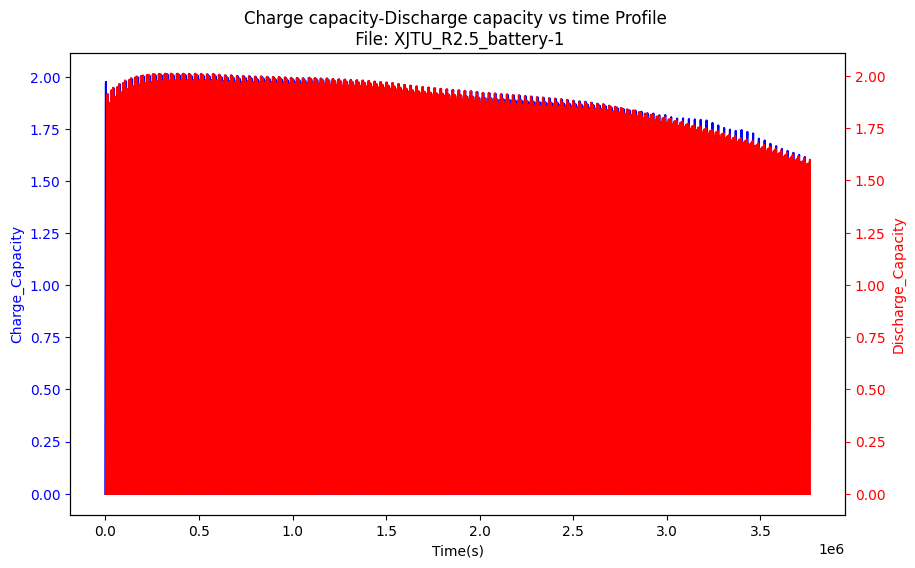

 40%|████      | 22/55 [01:45<02:58,  5.41s/it]

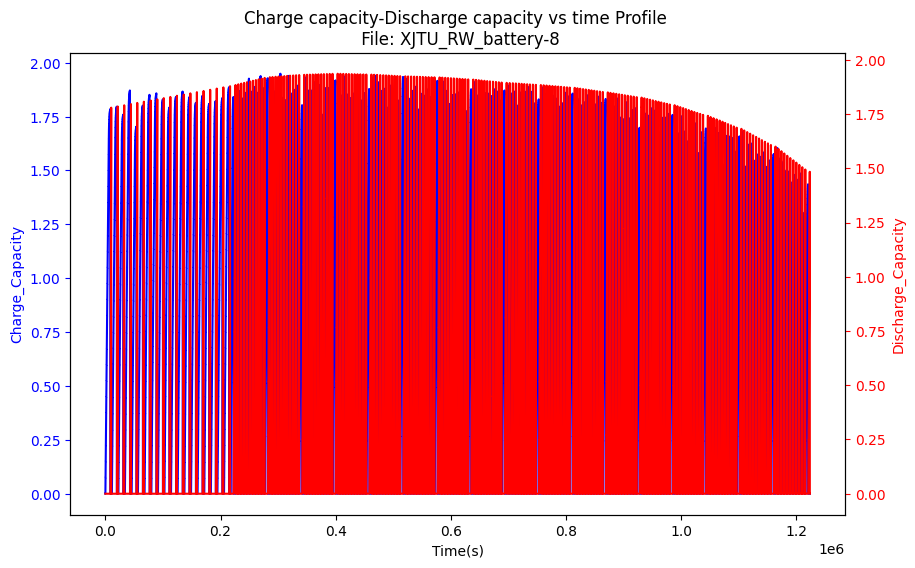

 42%|████▏     | 23/55 [01:47<02:17,  4.30s/it]

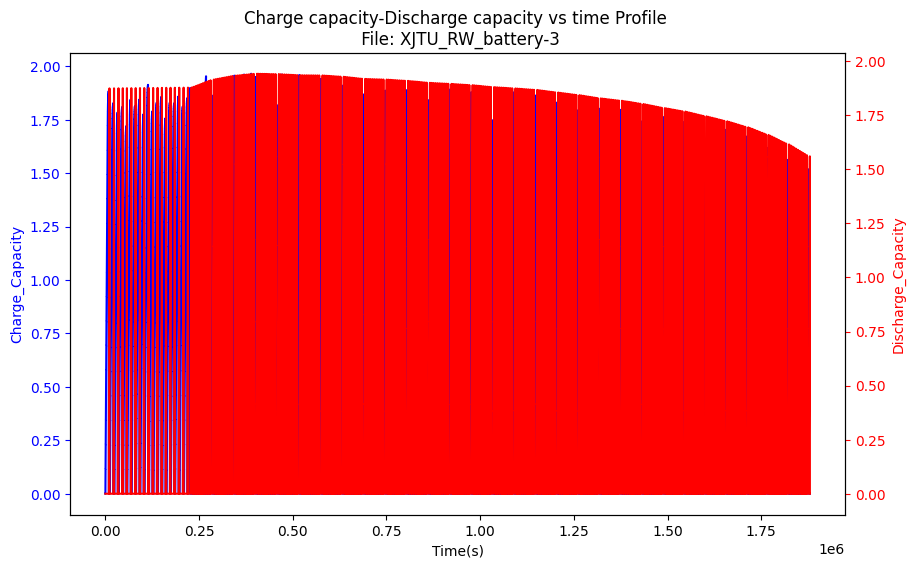

 44%|████▎     | 24/55 [01:49<01:55,  3.72s/it]

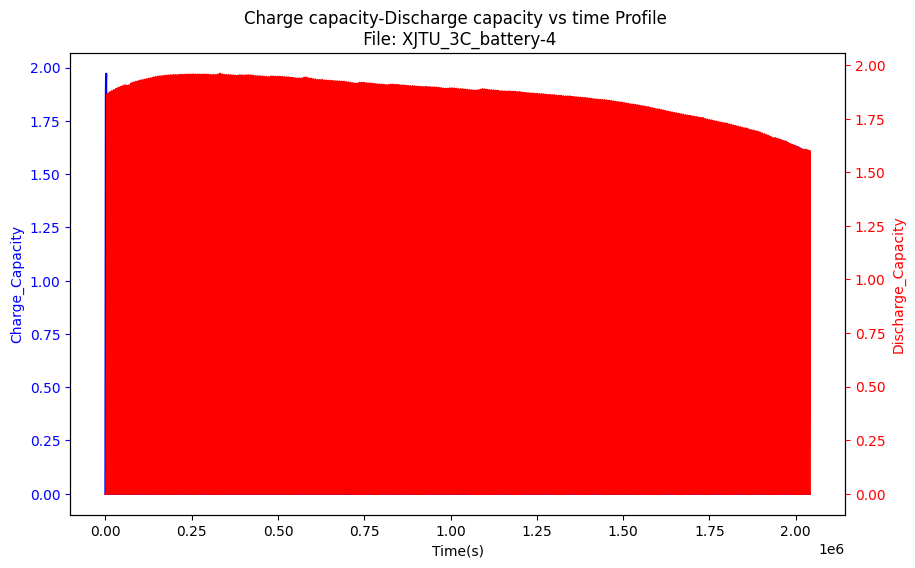

 45%|████▌     | 25/55 [01:52<01:44,  3.48s/it]

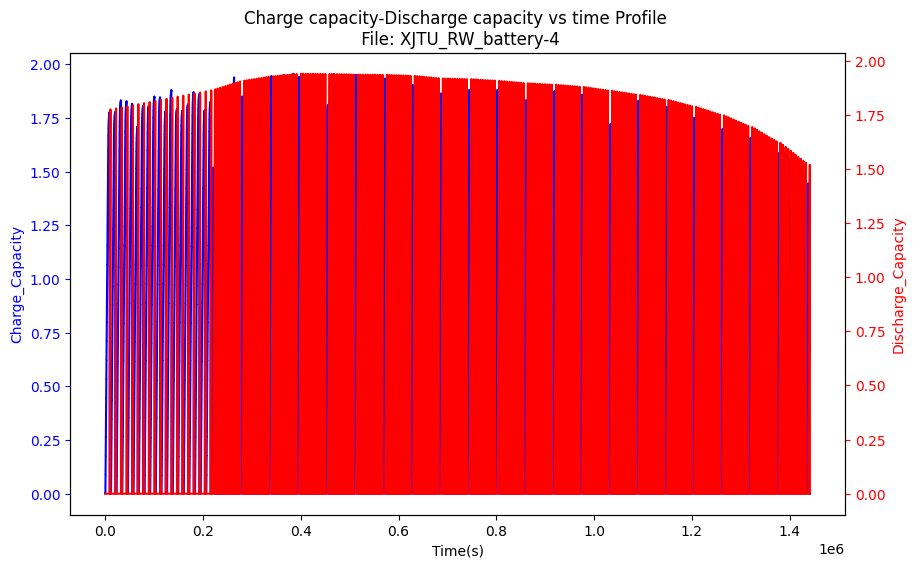

 47%|████▋     | 26/55 [01:54<01:26,  2.99s/it]

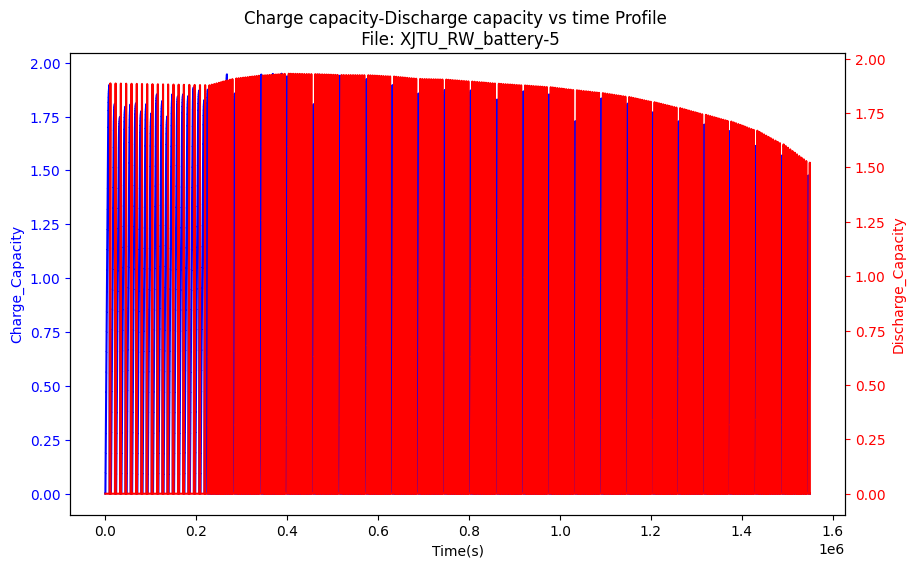

 49%|████▉     | 27/55 [01:56<01:15,  2.68s/it]

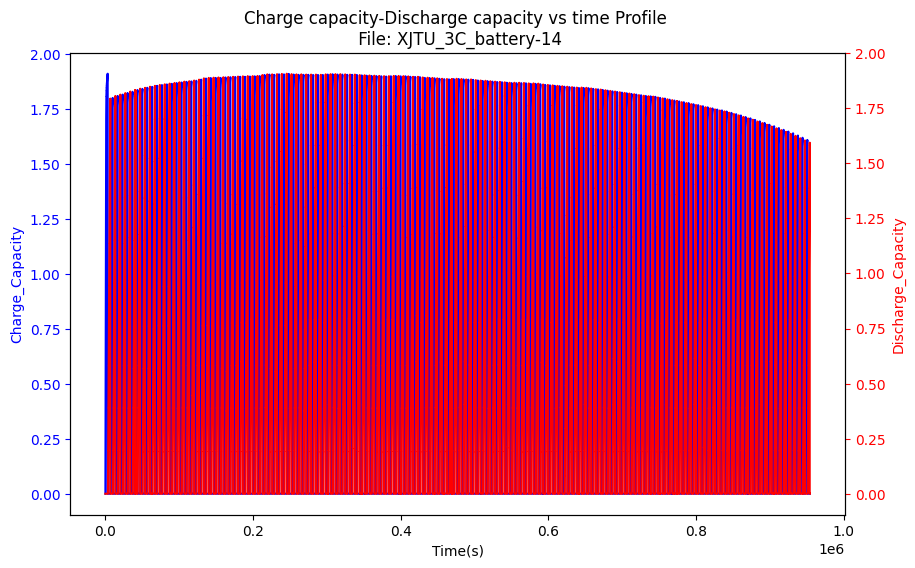

 51%|█████     | 28/55 [01:58<01:02,  2.30s/it]

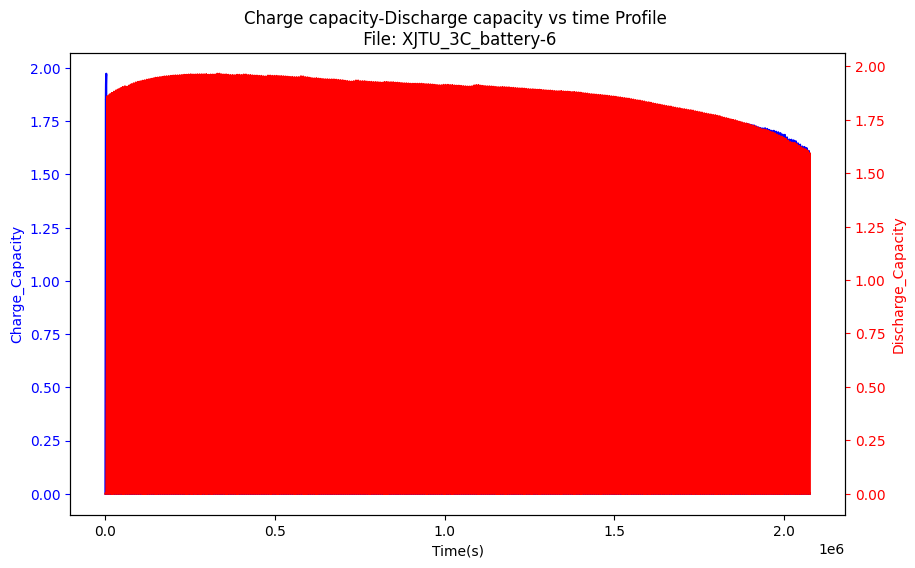

 53%|█████▎    | 29/55 [02:00<01:04,  2.50s/it]

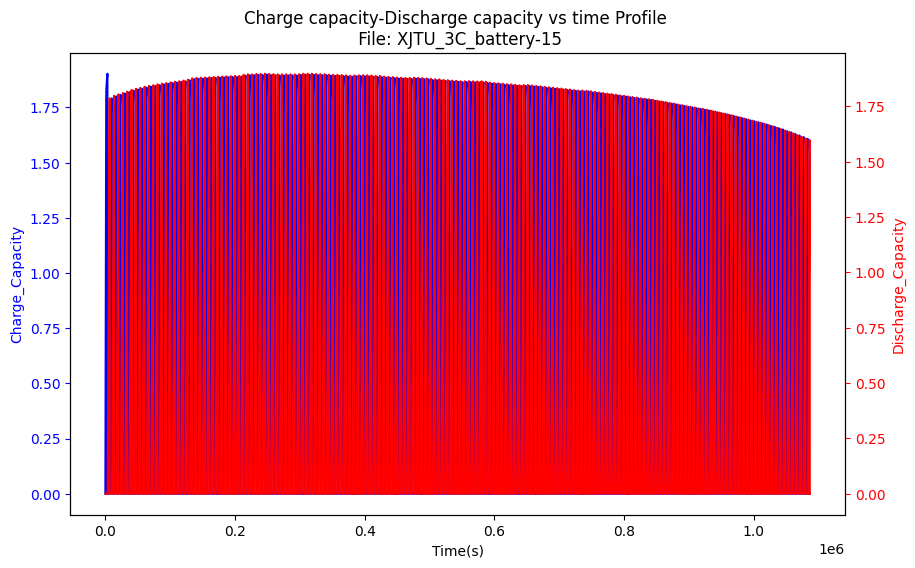

 55%|█████▍    | 30/55 [02:02<00:55,  2.23s/it]

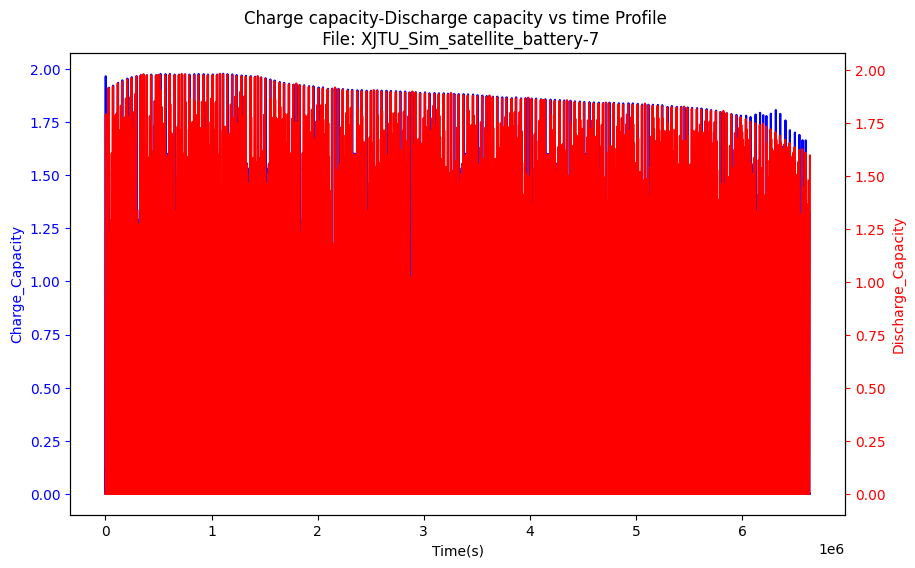

 56%|█████▋    | 31/55 [02:09<01:30,  3.75s/it]

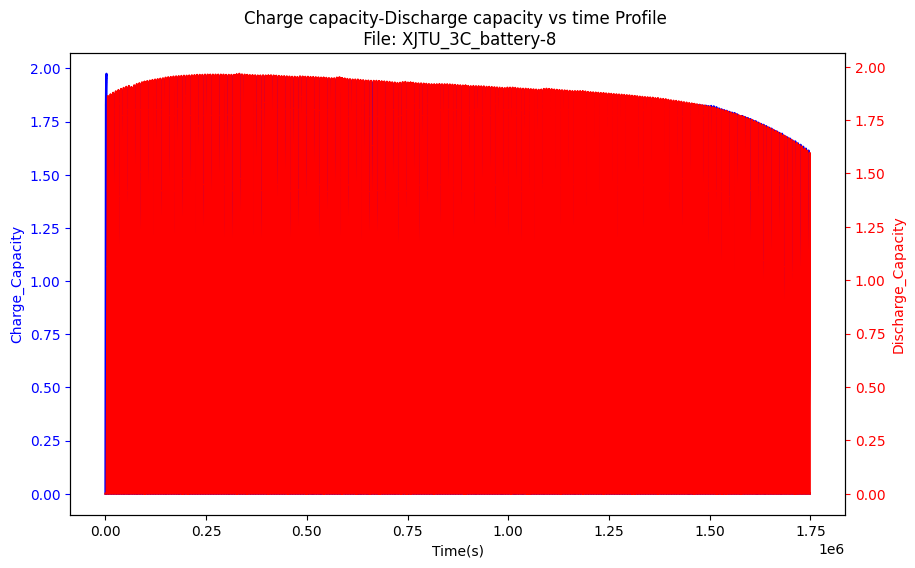

 58%|█████▊    | 32/55 [02:12<01:19,  3.46s/it]

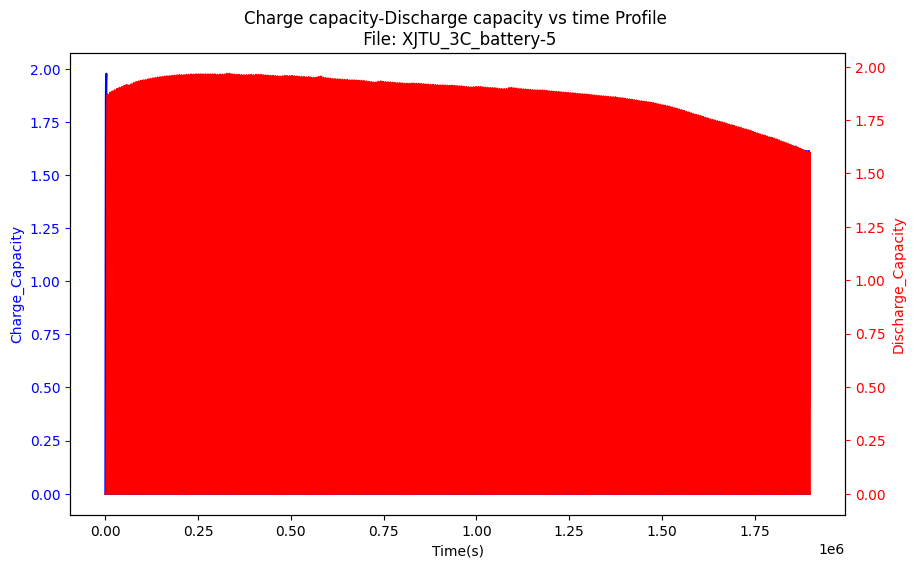

 60%|██████    | 33/55 [02:15<01:10,  3.19s/it]

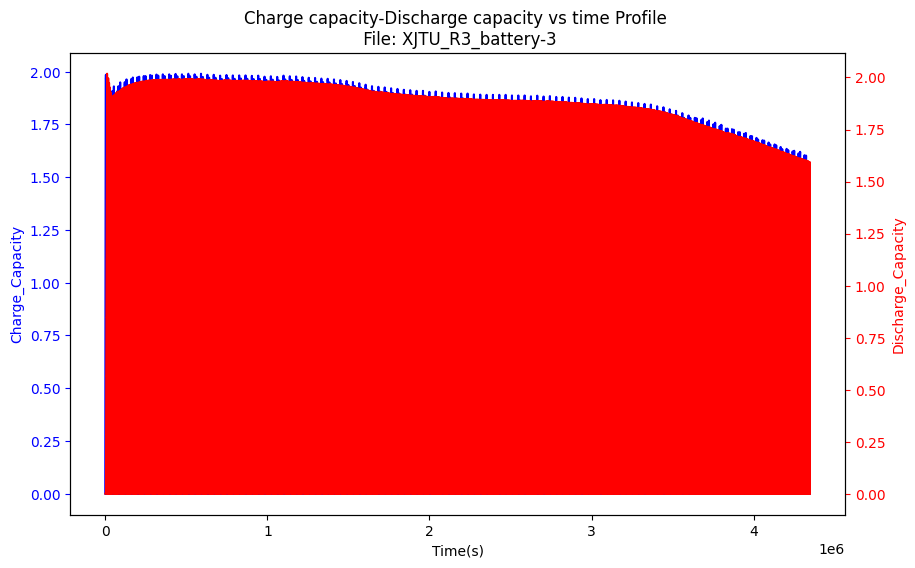

 62%|██████▏   | 34/55 [02:21<01:24,  4.00s/it]

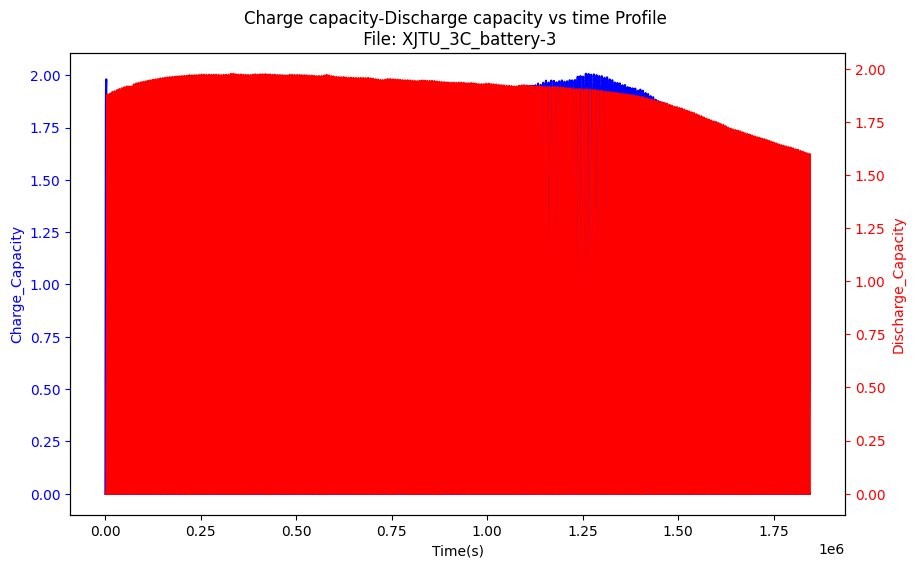

 64%|██████▎   | 35/55 [02:23<01:11,  3.60s/it]

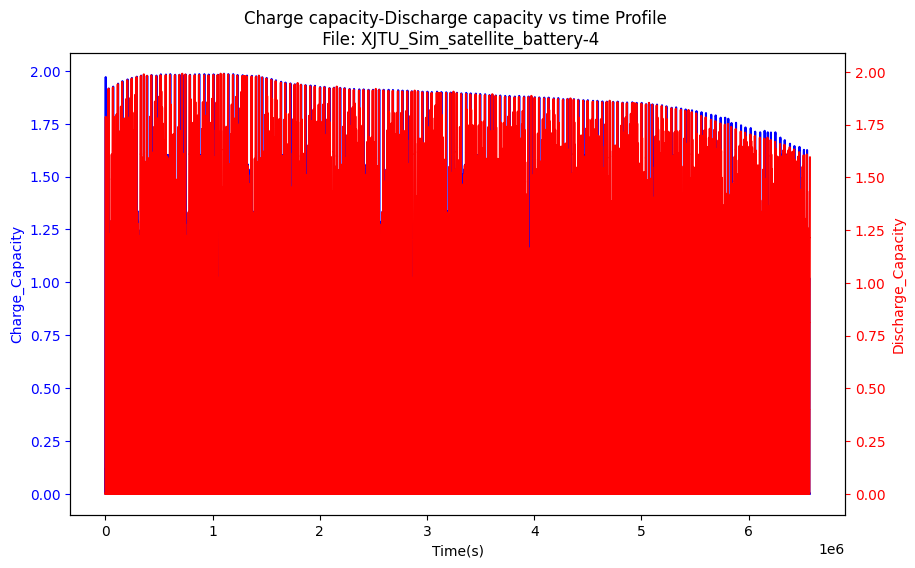

 65%|██████▌   | 36/55 [02:31<01:30,  4.77s/it]

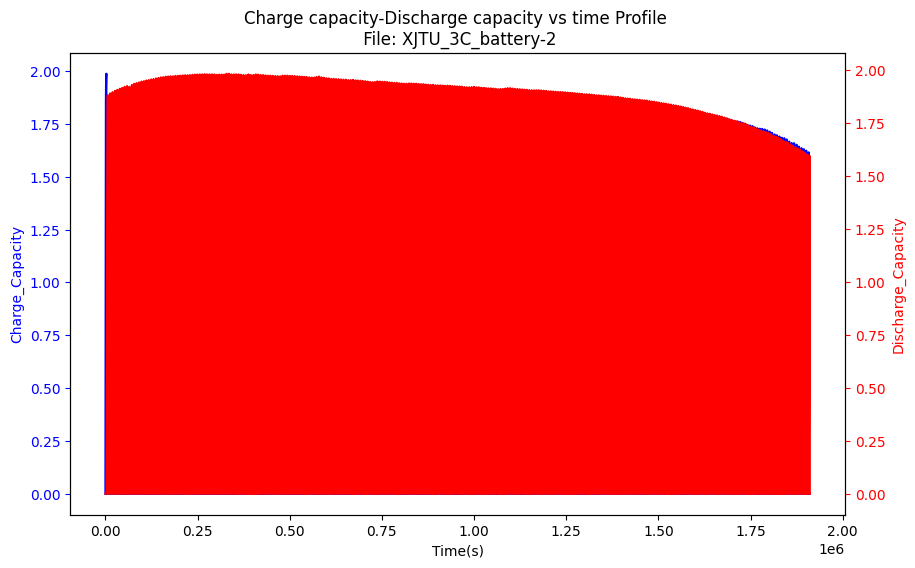

 67%|██████▋   | 37/55 [02:34<01:16,  4.26s/it]

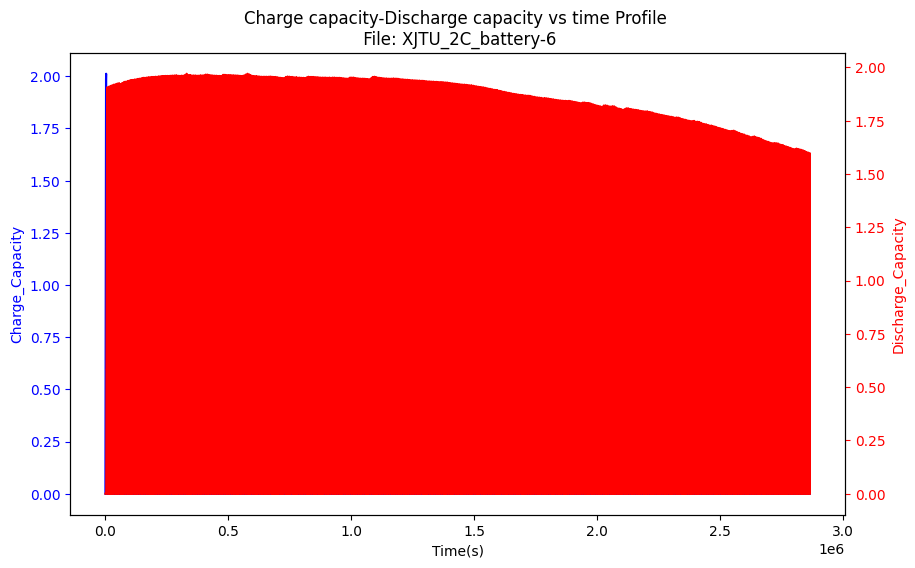

 69%|██████▉   | 38/55 [02:38<01:09,  4.10s/it]

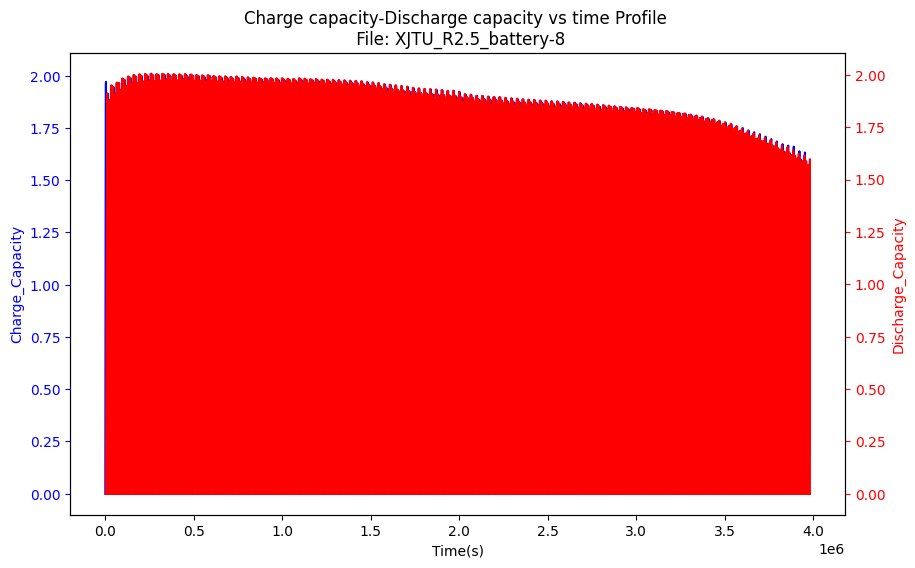

 71%|███████   | 39/55 [02:43<01:12,  4.53s/it]

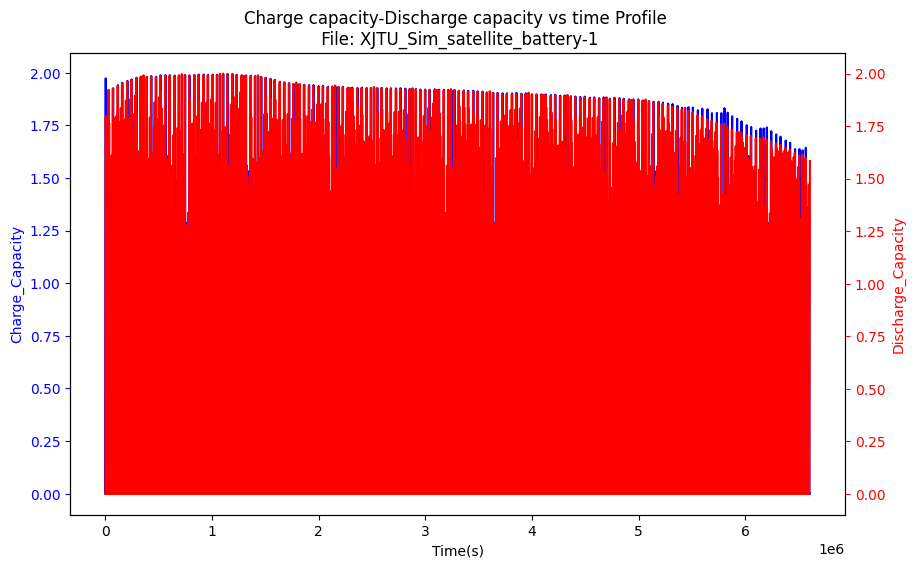

 73%|███████▎  | 40/55 [02:51<01:21,  5.46s/it]

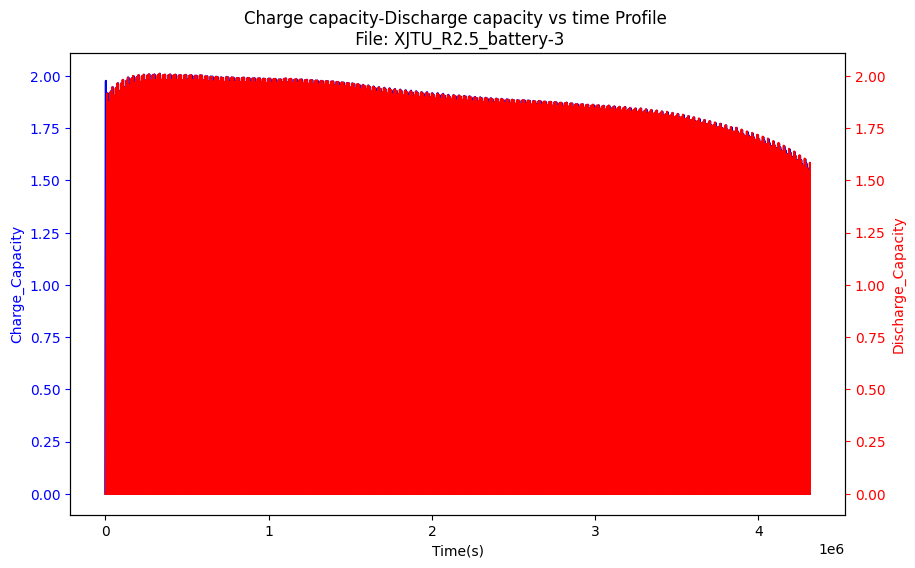

 75%|███████▍  | 41/55 [02:57<01:19,  5.69s/it]

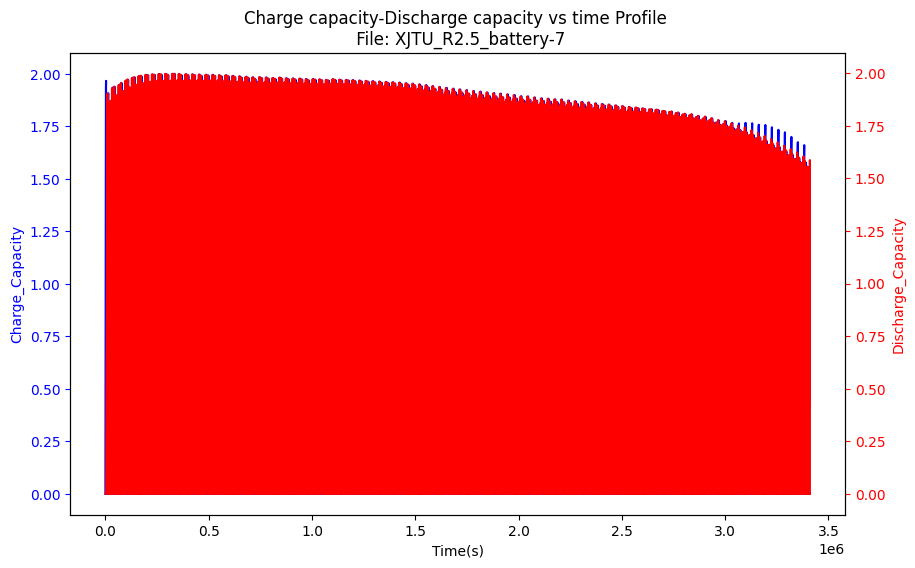

 76%|███████▋  | 42/55 [03:02<01:09,  5.38s/it]

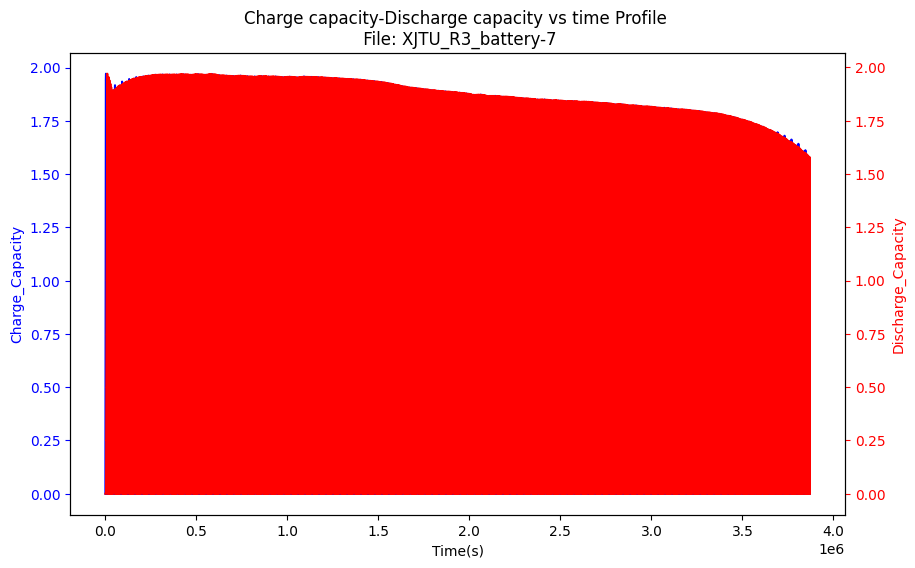

 78%|███████▊  | 43/55 [03:06<01:02,  5.18s/it]

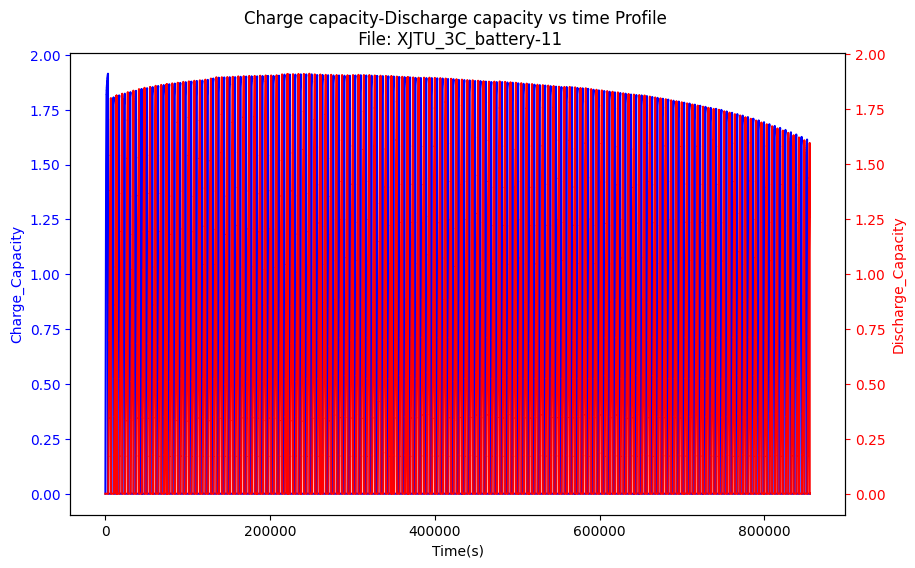

 80%|████████  | 44/55 [03:08<00:44,  4.06s/it]

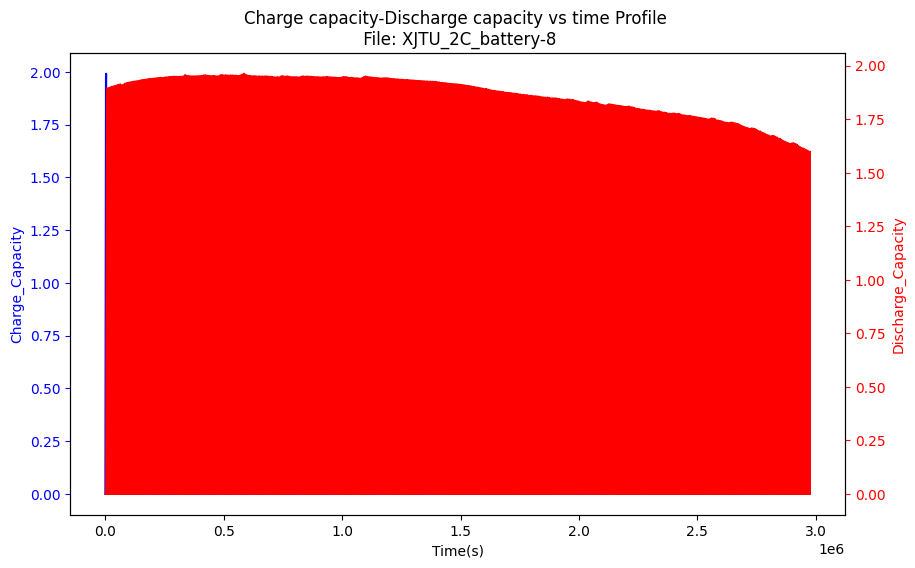

 82%|████████▏ | 45/55 [03:12<00:39,  3.99s/it]

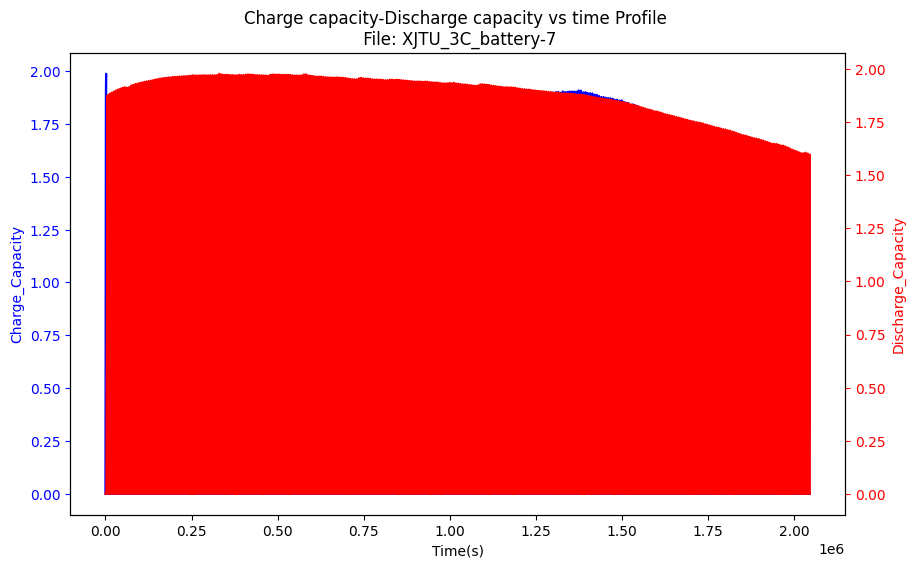

 84%|████████▎ | 46/55 [03:15<00:32,  3.66s/it]

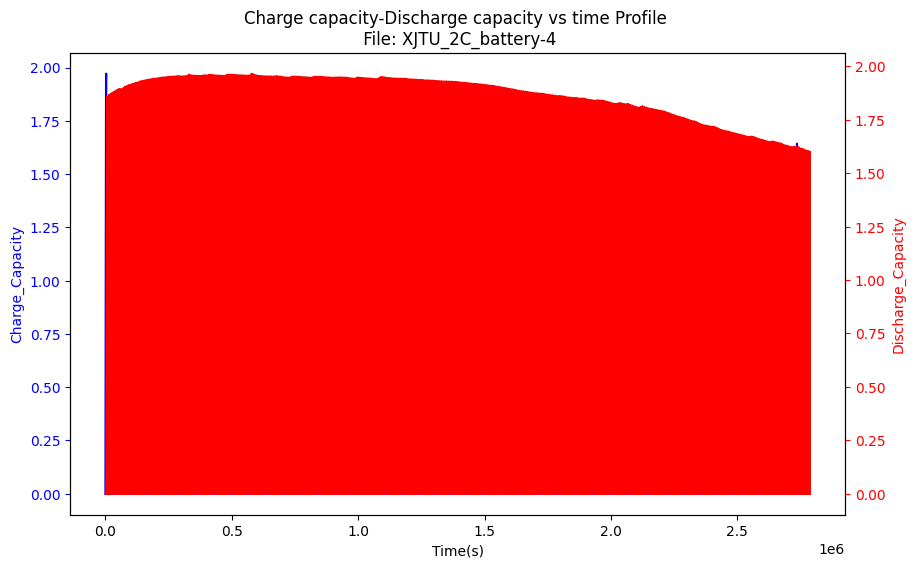

 85%|████████▌ | 47/55 [03:18<00:29,  3.67s/it]

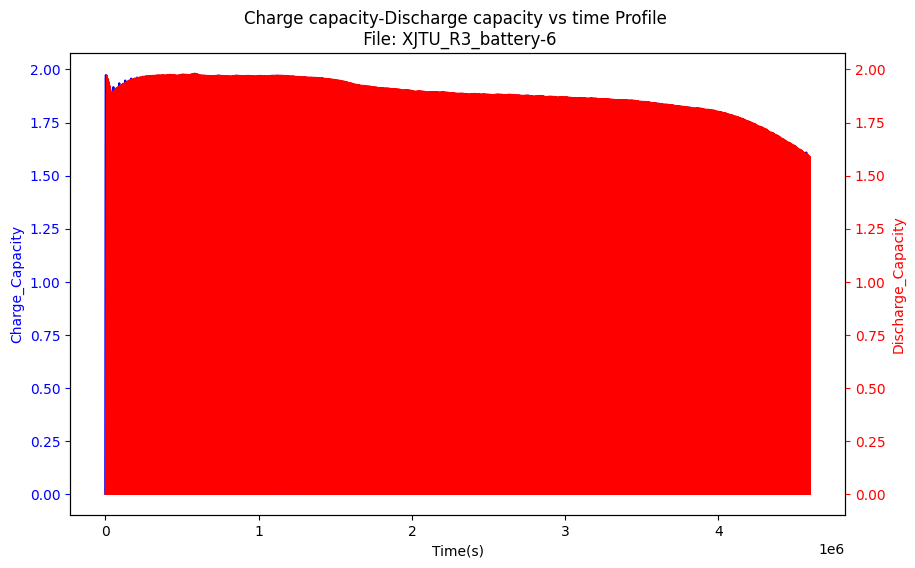

 87%|████████▋ | 48/55 [03:24<00:30,  4.41s/it]

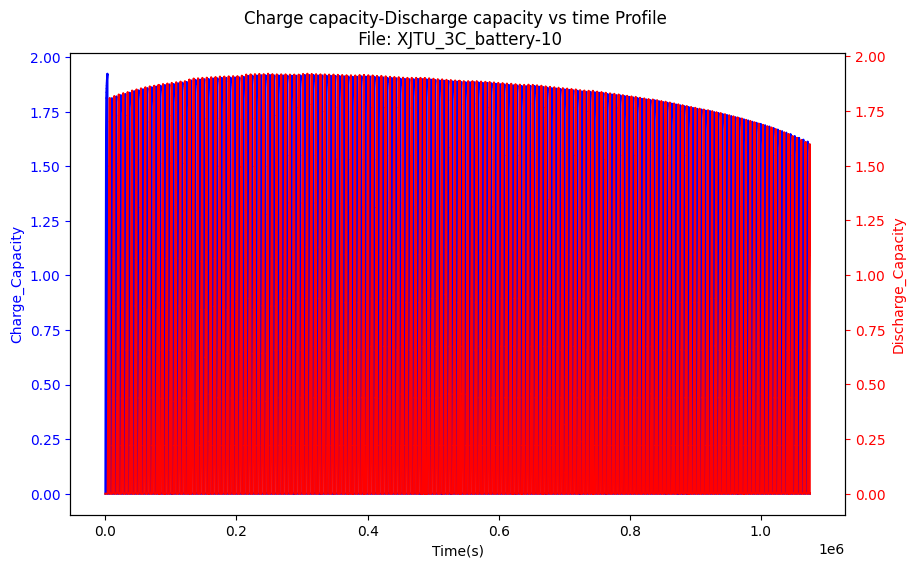

 89%|████████▉ | 49/55 [03:26<00:21,  3.61s/it]

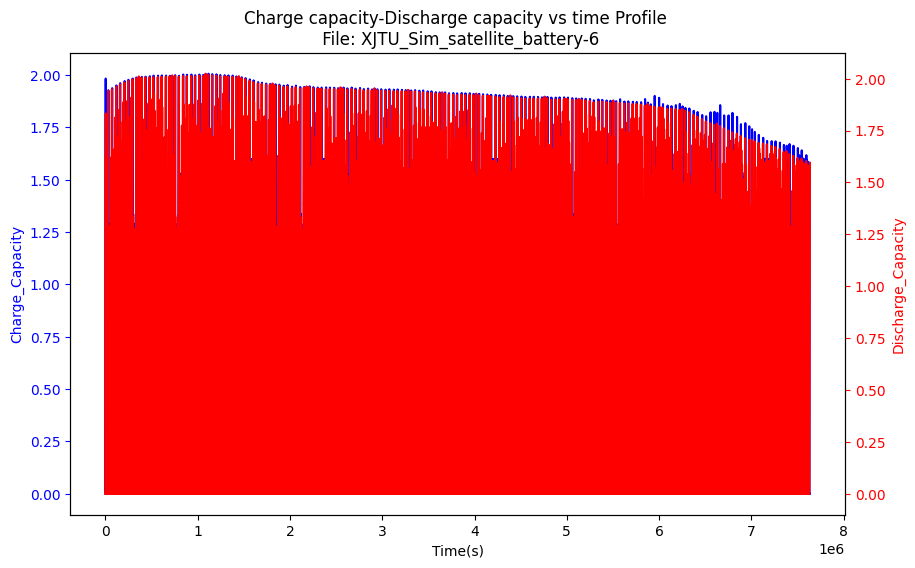

 91%|█████████ | 50/55 [03:35<00:25,  5.15s/it]

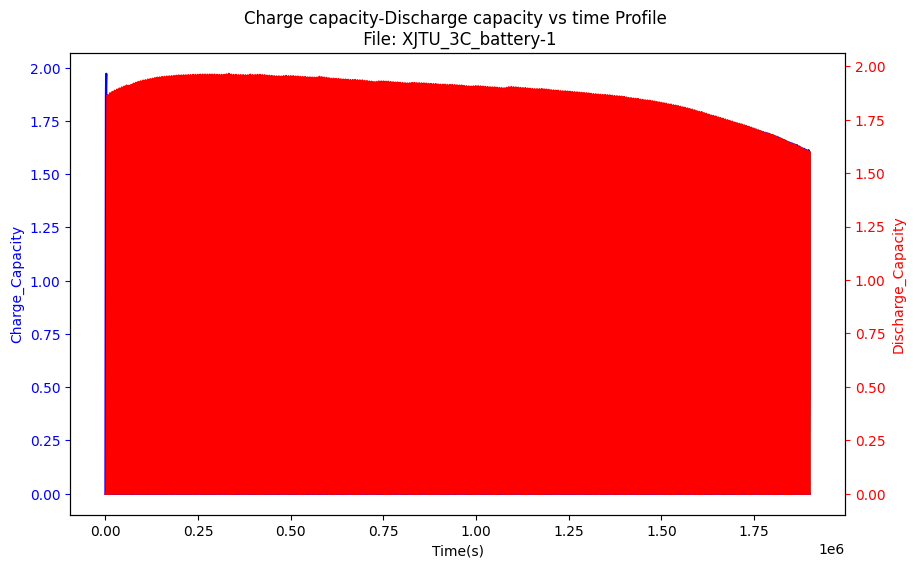

 93%|█████████▎| 51/55 [03:38<00:18,  4.55s/it]

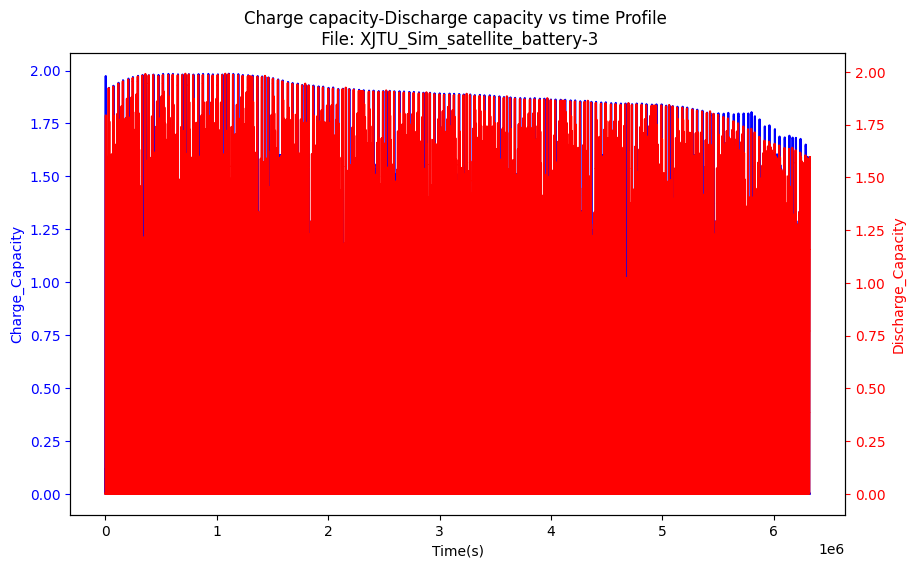

 95%|█████████▍| 52/55 [03:45<00:15,  5.28s/it]

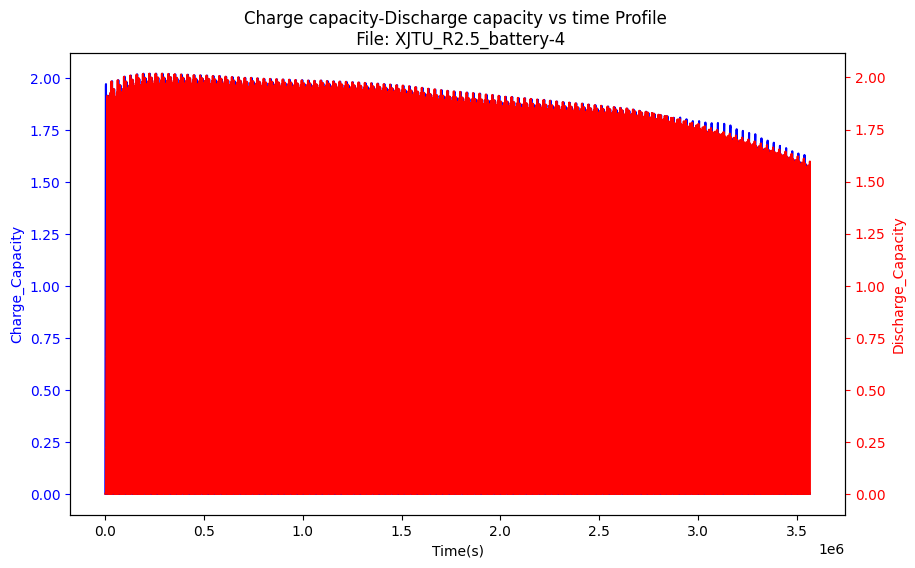

 96%|█████████▋| 53/55 [03:50<00:10,  5.30s/it]

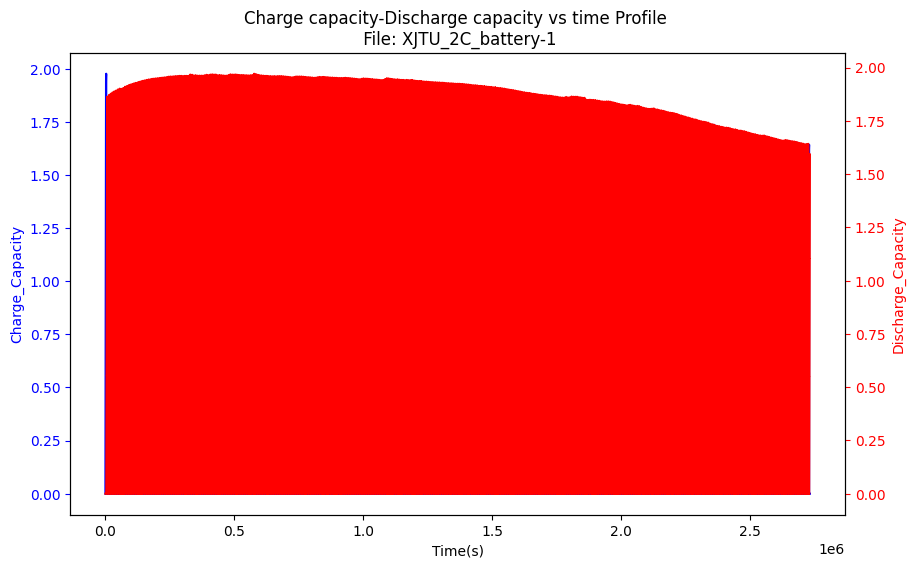

 98%|█████████▊| 54/55 [03:54<00:04,  4.80s/it]

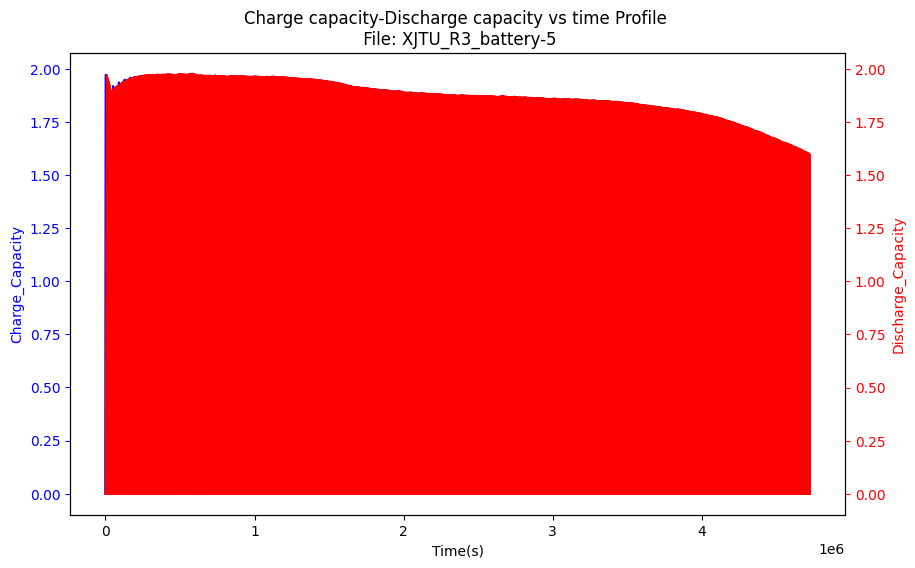

100%|██████████| 55/55 [04:01<00:00,  4.38s/it]


In [ ]:
import os
import pickle
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL.ImageColor import colormap
from sympy.physics.control.control_plots import matplotlib
from tqdm import tqdm
import seaborn as sns
import numpy as np

path = '/data/ljk/BatteryLife/datasets/processed/XJTU/' # enter the dataset path
ppath = Path(path)
files = os.listdir(path)
files = [i for i in files if i.endswith('.pkl')]
soc = []
cell = []

life_label = []
data = {}
for file in tqdm(files):
    with open(path + f'{file}', 'rb') as f:
        cell_data = pickle.load(f)
        filename = file.split('.pkl')[0]
        length = len(cell_data['cycle_data'])
        capacity = cell_data['nominal_capacity_in_Ah']
        df = pd.DataFrame()
        soh = []
        cycles = 0
        charge_caps = []
        discharge_caps = []
        times = []
        for i in range(0, length):
            # if i > 10:
            #     break

            cycle_df = pd.DataFrame()
            cycle_data_len = len(cell_data['cycle_data'][i])
            cycle_data = cell_data['cycle_data'][i]

            cycle_df['current'] = cycle_data['current_in_A']
            cycle_df['voltage'] = cycle_data['voltage_in_V']
            cycle_df['charge_capacity'] = cycle_data['charge_capacity_in_Ah']
            cycle_df['discharge_capacity'] = cycle_data['discharge_capacity_in_Ah']
            cycle_df['test time'] = cycle_data['time_in_s']
            cycle_df['cycle_number'] = cycle_data['cycle_number']
            soh_value = cycle_df.loc[cycle_df['current'] < 0, 'discharge_capacity'].max()

            charge_cap = cycle_df['charge_capacity'].values.tolist()
            discharge_cap = cycle_df['discharge_capacity'].values.tolist()
            time = cycle_df['test time'].values.tolist()

            charge_caps += charge_cap
            discharge_caps += discharge_cap
            times += time

        fig, ax1 = plt.subplots(figsize=(10, 6))

        ax1.plot(times, charge_caps, 'b-')
        ax1.set_xlabel('Time(s)')
        ax1.set_ylabel('Charge_Capacity', color='b')
        ax1.tick_params('y', colors='b')

        ax2 = ax1.twinx()
        ax2.plot(times, discharge_caps, 'r-')
        ax2.set_ylabel('Discharge_Capacity', color='r')
        ax2.tick_params('y', colors='r')

        plt.title('Charge capacity-Discharge capacity vs time Profile \n File: {}'.format(filename))
        plt.show()

